<a href="https://colab.research.google.com/github/cankurt-netizen/DSA210-PROJECT/blob/main/H4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving prices.csv to prices.csv


In [45]:
import pandas as pd

df = pd.read_csv("prices.csv")

price_usd = df[df["Element"] == "Producer Price (USD/tonne)"][["Year", "Value"]]
price_usd = price_usd.rename(columns={"Value": "Price_USD"})

price_usd["Year"] = pd.to_numeric(price_usd["Year"], errors="coerce")
price_usd["Price_USD"] = pd.to_numeric(price_usd["Price_USD"], errors="coerce")
price_usd = price_usd.dropna()

local_mask = df["Element"].astype(str).str.contains("Local Currency", case=False, na=False)

if local_mask.any():
    price_local = df[local_mask][["Year", "Value"]].copy()
    price_local = price_local.rename(columns={"Value": "Price_Local"})

    price_df = pd.merge(price_usd, price_local, on="Year", how="inner")

    print("\nLocal currency data found in FAOSTAT.")
else:
    price_df = price_usd.copy()
    price_df["Price_Local_SAR"] = price_df["Price_USD"] * 3.75

price_df = price_df.sort_values("Year").reset_index(drop=True)
price_df.head()

,Year,Price_USD,Price_Local_SAR
0,2000,3263.3,12237.375
1,2001,3313.1,12424.125
2,2002,3307.1,12401.625
3,2003,3312.5,12421.875
4,2009,3781.3,14179.875


In [39]:
from google.colab import files
uploaded = files.upload()

Saving production (2).csv to production (2) (1).csv


In [60]:
import pandas as pd
import numpy as np

df_prod = pd.read_csv("production (2).csv")

prod_df = df_prod[df_prod["Element"] == "Production"].copy()


prod_df = prod_df[["Year", "Value"]]
prod_df = prod_df.rename(columns={"Value": "Production"})


prod_df["Year"] = pd.to_numeric(prod_df["Year"], errors="coerce")
prod_df["Production"] = pd.to_numeric(prod_df["Production"], errors="coerce")

prod_df = prod_df.sort_values("Year").reset_index(drop=True)
prod_df["Log_Production"] = np.log(prod_df["Production"])
prod_df.head()

,Year,Production,Log_Production
0,2000,734844.0,13.507414
1,2001,817887.0,13.614479
2,2002,829540.0,13.628627
3,2003,884088.0,13.692312
4,2004,941293.0,13.755010


In [61]:
merged = pd.merge(price_df, prod_df, on="Year", how="inner")
merged.head()

,Year,Price_USD,Price_Local_SAR,Production,Log_Production
0,2000,3263.3,12237.375,734844.0,13.507414
1,2001,3313.1,12424.125,817887.0,13.614479
2,2002,3307.1,12401.625,829540.0,13.628627
3,2003,3312.5,12421.875,884088.0,13.692312
4,2009,3781.3,14179.875,991660.0,13.807136


In [59]:
from scipy.stats import spearmanr

corr_usd, p_usd = spearmanr(merged["Production"], merged["Price_USD"])
corr_sar, p_sar = spearmanr(merged["Production"], merged["Price_Local_SAR"])

print("USD Correlation:", corr_usd, "p-value:", p_usd)
print("SAR Correlation:", corr_sar, "p-value:", p_sar)


USD Correlation: -0.27555948242923645 p-value: 0.25350690764450096
SAR Correlation: -0.27555948242923645 p-value: 0.25350690764450096


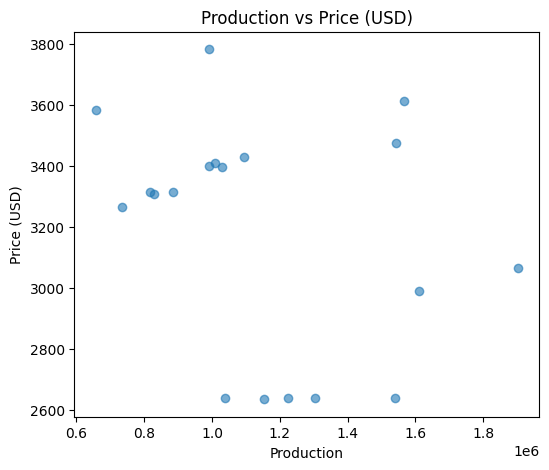

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(merged["Production"], merged["Price_USD"], alpha=0.6)

plt.xlabel("Production")
plt.ylabel("Price (USD)")
plt.title("Production vs Price (USD)")

plt.show()

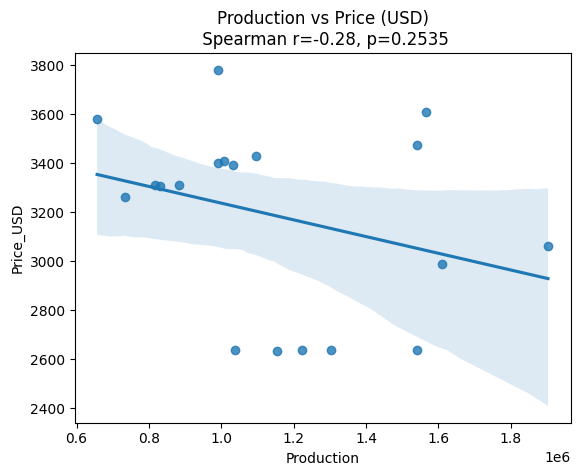

In [56]:
import seaborn as sns

sns.regplot(x="Production", y="Price_USD", data=merged)

plt.title(f"Production vs Price (USD)\n Spearman r={corr_usd:.2f}, p={p_usd:.4f}")
plt.show()

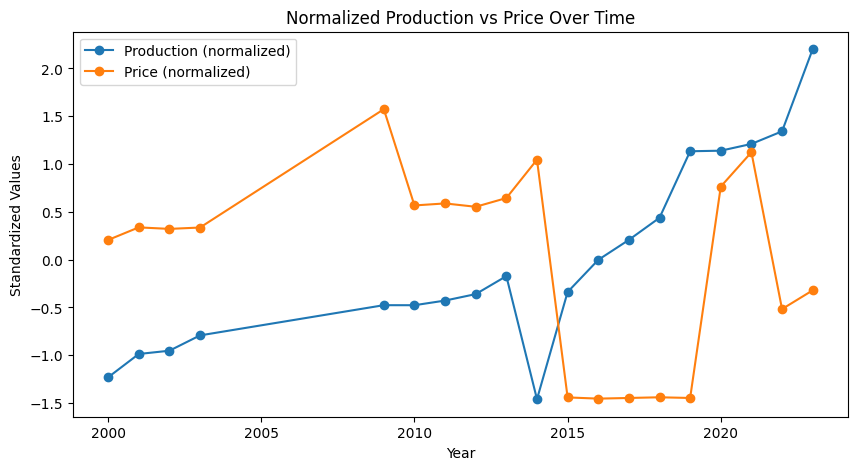

In [ ]:
merged["Production_norm"] = (merged["Production"] - merged["Production"].mean()) / merged["Production"].std()
merged["Price_norm"] = (merged["Price_USD"] - merged["Price_USD"].mean()) / merged["Price_USD"].std()

plt.figure(figsize=(10,5))

plt.plot(merged["Year"], merged["Production_norm"], marker="o", label="Production (normalized)")
plt.plot(merged["Year"], merged["Price_norm"], marker="o", label="Price (normalized)")

plt.title("Normalized Production vs Price Over Time")
plt.xlabel("Year")
plt.ylabel("Standardized Values")

plt.legend()
plt.show()

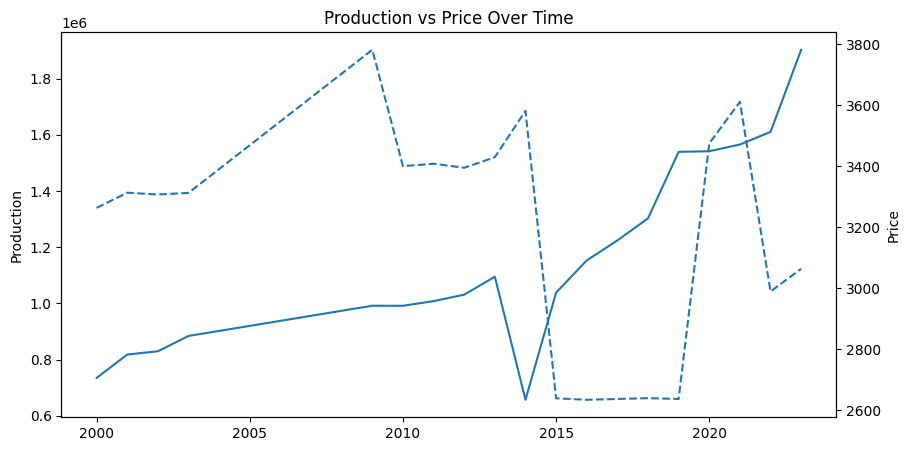

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(merged["Year"], merged["Production"], label="Production")
ax1.set_ylabel("Production")

ax2 = ax1.twinx()
ax2.plot(merged["Year"], merged["Price_USD"], linestyle="--", label="Price (USD)")
ax2.set_ylabel("Price")

plt.title("Production vs Price Over Time")

plt.show()